<a href="https://colab.research.google.com/github/YefridC09/ST-554-Project1-Template/blob/main/Task2/st554_project1_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Author: Eleanor Warren
###Date: 2/17/2026
###Purpose: First Draft

Time series data for air quality measurements in Italy.

- True measurements of air pollutants
- Sensor measurements of pollutants
- Weather-related measurements

This notebook should include:
- Introduction/narrative/section headers/charts and graphs

## Reading the Paper and Taking Notes:

- Dataset contains 9358 instances of hourly averaged responses from an array of 5 metal oxide chemical sensors.
- Device was located in a significantly polluted area/road level/Italian city
- Timeline: March 2004 to Feb 2005 (1 year)
- "Ground Truth" hourly averaged conentrations of chems.
- Has missing values? Yes, represented by -200.
- This data was specifically used in an intro paper that wants to predict benzene concentration with the goal of monitoring urban envrionment pollution.
- Benzene is of interest because it's known to induce cancers.

- It seems like the goal of the paper is to show that you can use gas multi-sensors (electronic noses) to help gather more pollutant data.

- If certain pollutants are correlated, then they could estimate levels of pollutants that they aren't specifically measuring based on levels of a correlated pollutant.

- "We present the results of the evaluation of an on-field, multi-variate calibration of a multi-sensor device, based on seven solid-state sensors..." The work was targeted at the estimation of CO, NOx, NO2, and Benzene concentrations.

- The performance of their multi-sensor device is characterized by the estimation error with respect to conventional station output, investigating the influence of training length (does more time make it a better measure? Is there a period of time that provides optimal measures?)


In [286]:
!pip install ucimlrepo

## modify column names or do other manipulations

Question 1: How is this data stored?

This data is stored as a pandas dataframe and access through a repo that contains a dictionary with values for data, metadata, and variable info.

There are 15 variables in this dataset.


In [287]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime as dt

# Keep air_quality as our repo dictionary
air_quality = fetch_ucirepo(id=360)
type(air_quality)

ucimlrepo.dotdict.dotdict

In [288]:
print(air_quality.metadata)

# This includes metadata including the unique UCI dataset identifier,
# name and data description, repo link, raw data file link, abstract,
# it seems that they use the term "features" to describe variables.
# This metadata says there are no missing values but the paper description says it does?

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [289]:
# This is great because it contains the units
# Note: this is telling us that some of the variables are categorical, that when
# I later use ".info()" are all shown as float.
print(air_quality.variables)

             name     role         type demographic  \
0            Date  Feature         Date        None   
1            Time  Feature  Categorical        None   
2          CO(GT)  Feature      Integer        None   
3     PT08.S1(CO)  Feature  Categorical        None   
4        NMHC(GT)  Feature      Integer        None   
5        C6H6(GT)  Feature   Continuous        None   
6   PT08.S2(NMHC)  Feature  Categorical        None   
7         NOx(GT)  Feature      Integer        None   
8    PT08.S3(NOx)  Feature  Categorical        None   
9         NO2(GT)  Feature      Integer        None   
10   PT08.S4(NO2)  Feature  Categorical        None   
11    PT08.S5(O3)  Feature  Categorical        None   
12              T  Feature   Continuous        None   
13             RH  Feature   Continuous        None   
14             AH  Feature   Continuous        None   

                                          description       units  \
0                                                N

In [290]:
# Saving the actual data (features) to a separate object for us to analyze.
air_data_full = air_quality.data.features

# What type is our data set? Confirming it's a pandas dataset
type(air_data_full) #Pandas Dataframe - this lets us know how to treat it.

pandas.core.frame.DataFrame

In [291]:
# Get the list of variables in the data set
air_data_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [292]:
# Create a rename function?

#def my_rename(df, oldvar):
#    if "(GT)" in oldvar:
#        renamed_df = df.rename(columns=)
#return renamed_df


In [293]:
# Get variable names in a more compatible format for python by removing certain symbols

# first rename the "Ground Truth" vars
# naming C6H6 differently since we want to keep that one later on
air_data_full = air_data_full.rename(columns={"CO(GT)" : "CO_GT", "NMHC(GT)" : "NMHC_GT", \
                                    "C6H6(GT)" : "C6H6", "NOx(GT)" : "NOx_GT", \
                                    "NO2(GT)" : "NO2_GT"})
# rename the raw sensor readings
air_data_full = air_data_full.rename(columns={"PT08.S1(CO)" : "CO_S1", "PT08.S2(NMHC)" : "NMHC_S2", \
                                    "PT08.S3(NOx)" : "NOx_S3", "PT08.S4(NO2)" : "NO2_S4", \
                                    "PT08.S5(O3)" : "O3_S5"})
air_data_full.head()


,Date,Time,CO_GT,CO_S1,NMHC_GT,C6H6,NMHC_S2,NOx_GT,NOx_S3,NO2_GT,NO2_S4,O3_S5,T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


Just by looking at the first few data points, it stood out to me that the magnitude of the "ground truth" average hourly concentrations of certain chemicals (from "co-located reference certified analyzer[s]") seemed to be much smaller than the magnitude of the corresponding hourly averaged sensor responses. This is related to the cross-sensitivites of these sensors, and makes sense in the context of what this paper is trying to investigate, which is whether these sensors can be good supplemental tools for measuring gas concentrations anyway. However, we aren't going to be investigating the "ground truth" values other than Benzene (C6H6), so I will drop those from the dataset.

In [294]:
droplist = [var for var in air_data_full.columns if "_GT" in var]
print(droplist)
air_data = air_data_full.drop(columns = droplist)

['CO_GT', 'NMHC_GT', 'NOx_GT', 'NO2_GT']


Identify and recode missing variables, then drop them from the dataset.

In [295]:
# Recode missing values from -200 to NaN, since the documentation tells us explicilty -200
# represents missing values
air_data = air_data.replace(to_replace = -200, value = np.nan)

# Check out first few values
air_data.head()

,Date,Time,CO_S1,C6H6,NMHC_S2,NOx_S3,NO2_S4,O3_S5,T,RH,AH
0,3/10/2004,18:00:00,1360.0,11.9,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,1292.0,9.4,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,1402.0,9.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,1376.0,9.2,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1272.0,6.5,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888


In [296]:
# Get a sense of how many missing values are in this dataset
air_data.isnull().sum()

,0
Date,0
Time,0
CO_S1,366
C6H6,366
NMHC_S2,366
NOx_S3,366
NO2_S4,366
O3_S5,366
T,366
RH,366


In [297]:
# Now let's drop the missing values
air_data_clean = air_data.dropna()

We should do some basic data validation here by assessing if these statistics make sense now that we've dropped missing values from the data. The only thing that stands out as odd initially is the negative value for "T", but since that is the variable for temperature, and we can have negative temperatures, it's reasonable to assume that's not a data error.

In [298]:
# Quick overview analysis of all the numeric variables (everything but date and time)
# .describe() omits NaN, so the count and values are updated to exclude those missing values
air_data_clean.describe()

,CO_S1,C6H6,NMHC_S2,NOx_S3,NO2_S4,O3_S5,T,RH,AH
count,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,1099.833166,10.083105,939.153376,835.493605,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,217.080037,7.449820,266.831429,256.817320,346.206794,398.484288,8.832116,17.316892,0.403813
min,647.000000,0.100000,383.000000,322.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,937.000000,4.400000,734.500000,658.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1063.000000,8.200000,909.000000,806.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,1231.000000,14.000000,1116.000000,969.500000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,2040.000000,63.700000,2214.000000,2683.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


Focusing on Benzene (C6H6) specifically, we can get a picture of the measures of center and spread here. We will also include a quick histogram to understand the shape of these values.

In [299]:
# Numeric summaries of Benzene
air_data_clean[["C6H6"]].describe(percentiles = [0.05, 0.25, 0.50, 0.75, 0.99])

,C6H6
count,8991.000000
mean,10.083105
std,7.449820
min,0.100000
5%,1.700000
25%,4.400000
50%,8.200000
75%,14.000000
99%,34.310000
max,63.700000


[Text(0.5, 0, 'C6H6')]

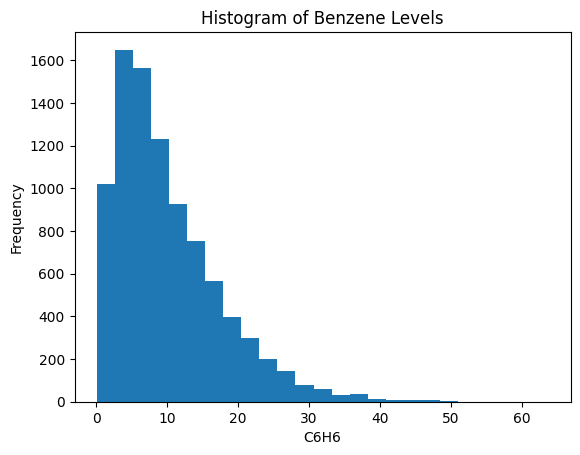

In [300]:
# Histogram of C6H6
air_data_clean.C6H6.plot.hist(bins = 25, title = "Histogram of Benzene Levels") \
    .set(xlabel = "C6H6")

Below is a line plot of Benzene (C6H6) over all of the dates observed. This is a really noisy chart, so let's see it at a lower time frequency.

Text(0, 0.5, 'microg/m^3')

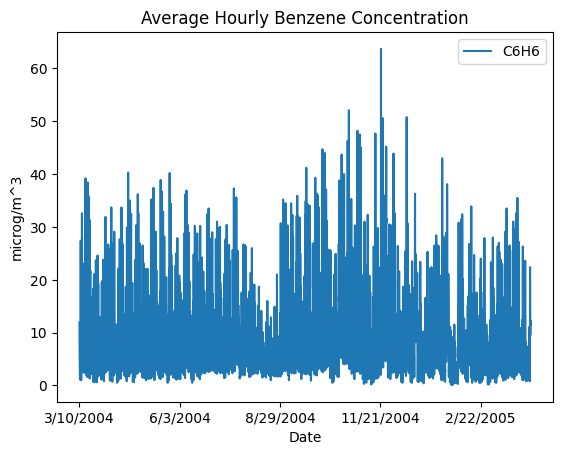

In [301]:
air_data_clean.plot("Date", "C6H6")
plt.title("Average Hourly Benzene Concentration")
plt.ylabel("microg/m^3")

In order to view benzene at a lower time frequency, I need to use the date variable to create a month-year only date, and then find the average for each month. I can't just extract the month by itself since our dataset spans a year and we want to ensure that we don't combine March from 2004 with March from 2005, for example. I don't think it would happen here since we only have March to Feb, but we want our code to be flexible.

In [302]:
# Create a month variable

# Combined information from the following sources:

# Source - https://stackoverflow.com/a/72181248
# Posted by jezrael
# Retrieved 2026-02-17, License - CC BY-SA 4.0

# Source - https://stackoverflow.com/a/59251840
# Posted by ATL
# Retrieved 2026-02-17, License - CC BY-SA 4.0

air_data_clean['Month'] = pd.to_datetime(air_data_clean['Date'], format='%m/%d/%Y').dt.to_period("M")
air_data_clean.head()

/tmp/ipython-input-4069590126.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_data_clean['Month'] = pd.to_datetime(air_data_clean['Date'], format='%m/%d/%Y').dt.to_period("M")


,Date,Time,CO_S1,C6H6,NMHC_S2,NOx_S3,NO2_S4,O3_S5,T,RH,AH,Month
0,3/10/2004,18:00:00,1360.0,11.9,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03
1,3/10/2004,19:00:00,1292.0,9.4,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,2004-03
2,3/10/2004,20:00:00,1402.0,9.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03
3,3/10/2004,21:00:00,1376.0,9.2,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03
4,3/10/2004,22:00:00,1272.0,6.5,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03


Text(0.5, 0, 'Date')

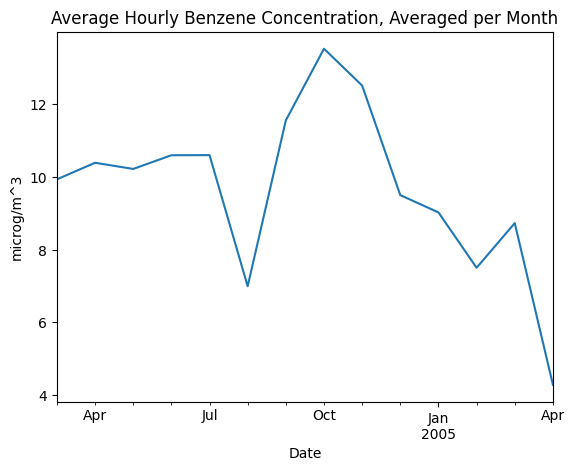

In [303]:
# Find the average over each month to make it a smoother line chart
benzene_means = air_data_clean.groupby("Month")["C6H6"].mean()
benzene_means.plot()
plt.title("Average Hourly Benzene Concentration, Averaged per Month")
plt.ylabel("microg/m^3")
plt.xlabel("Date")

I would be curious to know if the concentration of Benzene found in our atmosphere or in a city is continuously going up over time and at what rate, and if having a measure of Benzene at a given point in time gives us some sense of how much there would be after a given time period.

In [304]:
# Now if we want to see what the levels of Benzene are when there is low/med/high temperature.

# First, create a category variable that defines temperatures as low when they are the bottom
# 25%, med in the middle 50, and high when it's above 75%

air_data_clean["temp_levels"] = pd.cut(air_data_clean["T"], bins = [0, 11.8, 24.4, 44.6], labels = ["Low", "Med.", "High"])
air_data_clean["temp_levels"].value_counts()


/tmp/ipython-input-3725267493.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_data_clean["temp_levels"] = pd.cut(air_data_clean["T"], bins = [0, 11.8, 24.4, 44.6], labels = ["Low", "Med.", "High"])


,count
temp_levels,
Med.,4491
Low,2254
High,2232


Observe how the histogram peaks around slightly higher levels of benzene than for the other temperatures.

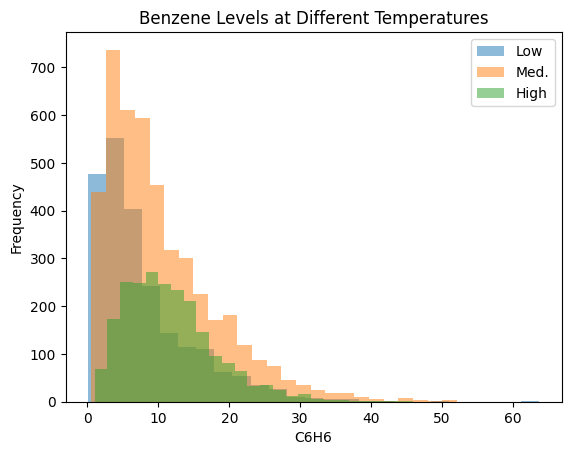

In [305]:
# Create histograms for Benzene levels across different temperatures.

benzene_low = air_data_clean.loc[air_data_clean.temp_levels == "Low","C6H6"]
benzene_med = air_data_clean.loc[air_data_clean.temp_levels == "Med.", "C6H6"]
benzene_high = air_data_clean.loc[air_data_clean.temp_levels == "High", "C6H6"]

benzene_low.plot.hist(bins = 25, alpha = 0.5, label = "Low",
                   title = "Benzene Levels at Different Temperatures") \
                   .set(xlabel = "C6H6")
benzene_med.plot.hist(bins = 25, alpha = 0.5, label = "Med.",
                   title = "Benzene Levels at Different Temperatures") \
                   .set(xlabel = "C6H6")
benzene_high.plot.hist(bins = 25, alpha = 0.5, label = "High",
                   title = "Benzene Levels at Different Temperatures") \
                   .set(xlabel = "C6H6")
plt.legend()


Start to investigate correlations

In [306]:
air_data_clean[["C6H6", "CO_S1", "NMHC_S2", "NOx_S3", "NO2_S4", "O3_S5"]].corr()

,C6H6,CO_S1,NMHC_S2,NOx_S3,NO2_S4,O3_S5
C6H6,1.000000,0.883795,0.981950,-0.735744,0.765731,0.865689
CO_S1,0.883795,1.000000,0.892964,-0.771938,0.682881,0.899324
NMHC_S2,0.981950,0.892964,1.000000,-0.796703,0.777254,0.880578
NOx_S3,-0.735744,-0.771938,-0.796703,1.000000,-0.538468,-0.796569
NO2_S4,0.765731,0.682881,0.777254,-0.538468,1.000000,0.591144
O3_S5,0.865689,0.899324,0.880578,-0.796569,0.591144,1.000000


In [307]:
#Temperature, relative humidity, absolute humidity
air_data_clean[["C6H6", "T", "RH", "AH"]].corr()

,C6H6,T,RH,AH
C6H6,1.000000,0.198956,-0.061681,0.167972
T,0.198956,1.000000,-0.578621,0.656397
RH,-0.061681,-0.578621,1.000000,0.167971
AH,0.167972,0.656397,0.167971,1.000000
